In [1]:
import torch

In [16]:
from DDPM import sample_v2, LinearNoiseScheduler
from DiT_v2 import DiT
from VAE import VAE

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vae = VAE(ch = 128, latent_channels = 4).to(device)

num_timesteps = 1000
beta_start    = 0.0001
beta_end      = 0.02


scheduler = LinearNoiseScheduler(num_timesteps  = num_timesteps,
                                     beta_start = beta_start,
                                     beta_end   = beta_end)


dit = DiT(d_model        = 256,
          g_channels       = 4,
          grid_size      = 32,
          patch_size     = 4,
          timestep_emb_dim  = 128,
        #   num_freq       = 128,
          num_layers     = 8,
          num_heads      = 4)

vae.eval()
dit.eval()

vae.load_state_dict(torch.load('vae_v2.pth', map_location = device))
dit.load_state_dict(torch.load('dit_v2.pth', map_location = device))

<All keys matched successfully>

In [20]:
img = sample_v2(32, dit, vae, device, scheduler)

1000it [00:32, 30.40it/s]


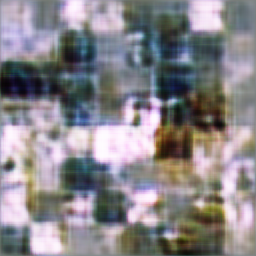

In [21]:
img